In [12]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

change the working directory to the project root

In [5]:
os.chdir(Path.cwd().parent)
print(Path.cwd())

/Users/scottsilvis/Git/github.com/clinical-notes-risk-stratification


read the patient.csv and outcomes.csv files and join them together by patient_id. 

In [8]:
patients = pd.read_csv(Path.cwd() / "src" / "data" / "processed" / "patients.csv")
outcomes = pd.read_csv(Path.cwd() / "src" / "data" / "processed" / "outcomes.csv")

df = patients.merge(outcomes, on="patient_id", how="inner")

Queston 1. What percentage of patients are readmitted to the hospital?

In [10]:
readmit_rate = df["readmit_30d"].mean()
print(f"Readmission Rate: {readmit_rate:.2%}")

Readmission Rate: 55.13%


Question 2. Do the predictors move in the expected ways?

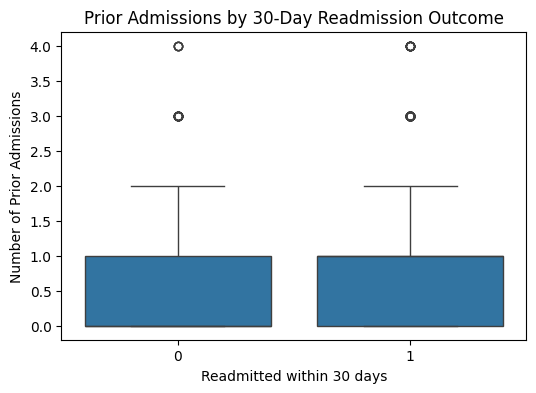

In [13]:
# Boxplot of Prior Admissions by Readmission Outcome
plt.figure(figsize=(6, 4))
sns.boxplot(
    x="readmit_30d",
    y="prior_admits",
    data=df
)
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of Prior Admissions")
plt.title("Prior Admissions by 30-Day Readmission Outcome")
plt.show()

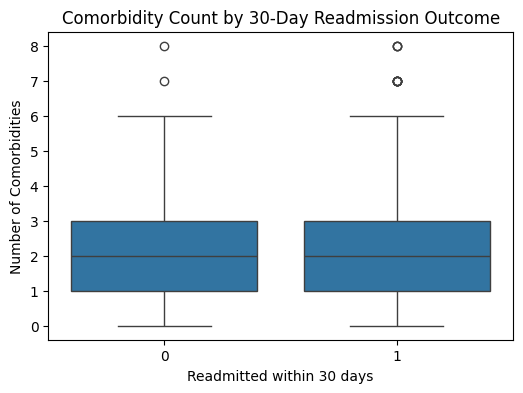

In [14]:
# Boxplot of Comorbidity Count by Readmission Outcome
plt.figure(figsize=(6, 4))
sns.boxplot(
    x="readmit_30d",
    y="comorbidity_count",
    data=df
)
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of Comorbidities")
plt.title("Comorbidity Count by 30-Day Readmission Outcome")
plt.show()

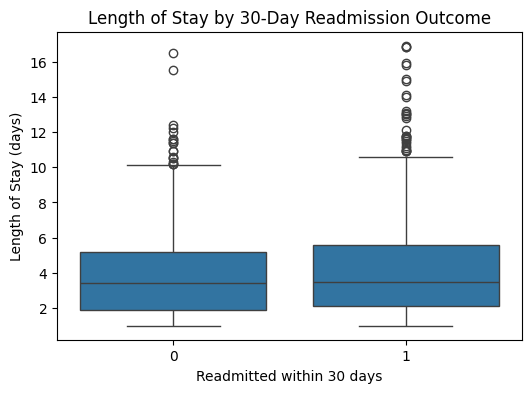

In [15]:
# Boxplot of Length of Stay by Readmission Outcome
plt.figure(figsize=(6, 4))
sns.boxplot(
    x="readmit_30d",
    y="los_days",
    data=df
)
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Length of Stay (days)")
plt.title("Length of Stay by 30-Day Readmission Outcome")
plt.show()

The univariate visualizations do not show strong separation for any single structured feature. However, the baseline logistic regression demonstrates predictive ability when these variables are considered jointly. This suggests that readmission risk in the dataset is explained by the combined effect of multiple features rather than by any single predictor.

Question 3. Are there any obvious data issues that would invalidate modeling or interpretation?

In [16]:
df.isna().sum()

patient_id           0
age                  0
sex                  0
comorbidity_count    0
prior_admits         0
los_days             0
readmit_30d          0
dtype: int64

In [17]:
df["patient_id"].duplicated().sum()

np.int64(0)

In [18]:
df[[
    "age",
    "comorbidity_count",
    "prior_admits",
    "los_days"
]].describe()

,age,comorbidity_count,prior_admits,los_days
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,57.007333,2.156000,0.817333,4.085733
std,15.342149,1.459138,0.910230,2.731165
min,18.000000,0.000000,0.000000,1.000000
25%,47.000000,1.000000,0.000000,2.000000
50%,57.000000,2.000000,1.000000,3.400000
75%,68.000000,3.000000,1.000000,5.425000
max,90.000000,8.000000,4.000000,16.900000


In [19]:
df["readmit_30d"].value_counts()

readmit_30d
1    827
0    673
Name: count, dtype: int64

Basic data quality checks revealed no missing values, duplicate patient records, or implausible feature ranges. The structured predictors fall within clinically reasonable bounds, and the outcome variable is binary with a moderately balanced distribution. Overall, the dataset appears suitable for baseline modeling and subsequent feature augmentation.